数据准备好了，共3305条记录
           Location  MinTemp  MaxTemp  Rainfall  Humidity3pm  Rain_lag1  \
Date                                                                      
2008-02-03   Sydney     21.6     24.5       6.6         86.0        6.0   
2008-02-04   Sydney     20.2     22.8      18.8         90.0        6.6   
2008-02-05   Sydney     19.7     25.7      77.4         74.0       18.8   
2008-02-06   Sydney     20.2     27.2       1.6         62.0       77.4   
2008-02-07   Sydney     18.6     26.3       6.2         80.0        1.6   

            Rain_lag2  Temp_lag1  
Date                              
2008-02-03       15.6       25.6  
2008-02-04        6.0       24.5  
2008-02-05        6.6       22.8  
2008-02-06       18.8       25.7  
2008-02-07       77.4       27.2  
模型准确率: 69.14%

特征重要性:
       feature  importance
3  Humidity3pm    0.413518
2    Temp_lag1    0.357328
0    Rain_lag1    0.116779
1    Rain_lag2    0.112375


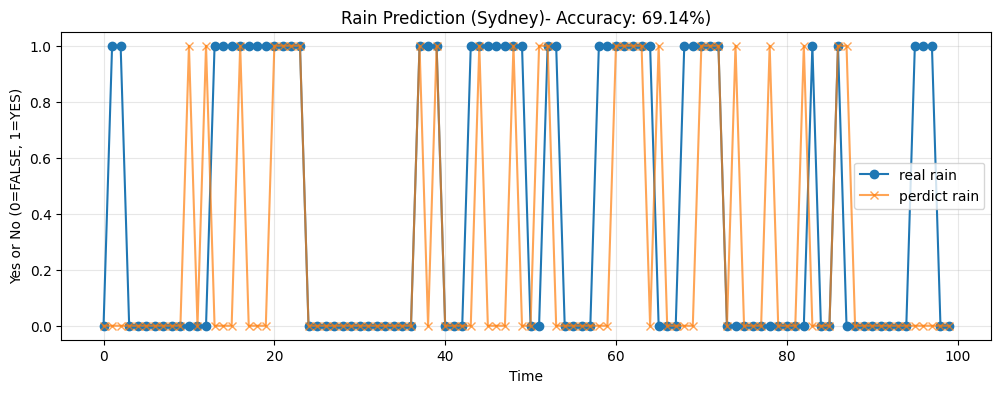

In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

df = pd.read_csv('weatherAUS.csv')

df = df[['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Humidity3pm']]

df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

city = 'Sydney'
df_city = df[df['Location'] == city].copy()

df_city['Rain_lag1'] = df_city['Rainfall'].shift(1)  # 昨天
df_city['Rain_lag2'] = df_city['Rainfall'].shift(2)  # 前天
df_city['Temp_lag1'] = df_city['MaxTemp'].shift(1)   # 昨天温度

df_city = df_city.dropna()

print(f"数据准备好了，共{len(df_city)}条记录")
print(df_city.head())

df_city['Will_Rain_Tomorrow'] = (df_city['Rainfall'].shift(-1) > 0).astype(int)
df_city = df_city.dropna()  # 删除最后一个NaN

X = df_city[['Rain_lag1', 'Rain_lag2', 'Temp_lag1', 'Humidity3pm']]
y = df_city['Will_Rain_Tomorrow']

# 2. 划分训练集和测试集（前80%训练，后20%测试）
split_point = int(len(X) * 0.8)
X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]

# 训练模型（极简版，不调参）
model = RandomForestClassifier(n_estimators=10, random_state=42)  # 只有10棵树，快
model.fit(X_train, y_train)

#预测
y_pred = model.predict(X_test)

# 5. 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率: {accuracy:.2%}")

# 6. 特征重要性（看看哪个因素最重要）
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print("\n特征重要性:")
print(importance)
# 画对比图（只看前100个测试点，太多看不清）
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:100], label='real rain', marker='o')
plt.plot(y_pred[:100], label='perdict rain', marker='x', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Yes or No (0=FALSE, 1=YES)')
plt.title(f'Rain Prediction ({city})- Accuracy: {accuracy:.2%})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('rain_prediction.png', dpi=150, bbox_inches='tight')
plt.show()